In [18]:
# DirectTrajOpt.jl, NamedTrajectories.jl
# Piccolo.jl
using Piccolo
using LinearAlgebra
using CairoMakie

In [19]:
δ12 = 2π * 0.05

XX = operator_from_string("XX")
YY = operator_from_string("YY")
XY = operator_from_string("XY")
YX = operator_from_string("YX")
XI = operator_from_string("XI")
IX = operator_from_string("IX")
YI = operator_from_string("YI")
IY = operator_from_string("IY")
IZ = operator_from_string("IZ")

bounds = [
    2π * 0.01,
    2π * 0.01,
    2π * 0.01,
    2π * 0.01,
    2π * 0.01,
]

function H(u, t)
    g = u[1]
    uX1, uY1 = u[2], u[3]
    uX2, uY2 = u[4], u[5]
    return (
        δ12/2 * IZ
        + g * ((XX + YY) * cos(δ12 * t) + (YX - XY) * sin(δ12 * t))
        + uX1 * XI + uY1 * YI
        + uX2 * IX + uY2 * IY
    )
end

H (generic function with 1 method)

Let's deal with robustness later.

Note: 
- Variational terms are not time dependent

In [20]:
sys = QuantumSystem(H, bounds)

QuantumSystem: levels = 4, n_drives = 5

In [21]:
"""
    sample(bounds::AbstractVector{Tuple}, n_samples::Int)

Sample the bounds uniformly with `n_samples` points.
"""
function sample(bounds::AbstractVector{Tuple{Float64,Float64}}, n_samples::Int)
    return [(high - low) * rand() + low for (low, high) in bounds, _ in 1:n_samples]
end

n_samples = 300
T = 100

# ZeroOrderPulse(sys::AbstractQuantumSystem, T::Real)
controls = sample(sys.drive_bounds, n_samples)
times = LinRange(0, T, n_samples)
# pulse = ZeroOrderPulse(controls, times)
pulse = LinearSplinePulse(controls, times)


LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}(DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}([-0.009435586209783055 0.0604471415063689 … 0.011828888323353257 -0.016863965765087377; 0.025426440389990076 0.03825545900821947 … 0.02043159488889934 0.010162787918529925; … ; -0.006302918286536355 0.04046465472252131 … -0.029188476834292154 0.04939388394820718; -0.024300209041507384 0.046934422675082854 … -0.003963873673145463 0.0565352792330551], [0.0, 0.33444816053511706, 0.6688963210702341, 1.0033444816053512, 1.3377926421404682, 1.6722408026755853, 2.0066889632107023, 2.341137123745819, 2.6755852842809364, 3.0100334448160537  …  96.98996655518395, 97.32441471571906, 97.65886287625418, 97.9933110367893, 98.32775919732441, 98.66220735785953, 98.99665551839465, 99.33110367892976, 99.66555183946488, 100.0], Union{}[], Dat

In [22]:
U_goal = exp(-im * π / 4 * (XX + YY))
qtraj = UnitaryTrajectory(sys, pulse, U_goal)

UnitaryTrajectory{LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}, SciMLBase.ODESolution{ComplexF64, 3, Vector{Matrix{ComplexF64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Matrix{ComplexF64}}}, Nothing, SciMLBase.ODEProblem{Matrix{ComplexF64}, Tuple{Float64, Float64}, true, SciMLBase.NullParameters, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, SciMLOperators.MatrixOperator{ComplexF64, Matrix{ComplexF64}, SciMLOperators.FilterKwargs{Nothing, Val{()}}, SciMLOperators.FilterKwargs{Piccolo.Quantum.Rollouts.var"#update!#6"{QuantumSystem{Piccolo.Quantum.QuantumSystems.var"#24#27"{typeof(H)}, Piccolo.Quantum.QuantumSystems.var"#25#28"{typeof(H)}, @NamedTuple{}, Vector{DriftTerm{SparseArrays.SparseMatrixCSC{ComplexF64, Int64}, Returns{Float64}, Returns{Float64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}, Val{()}}}, UniformScaling{Bool}, Nothing, Nothing, Nothing, Nothing, 

In [23]:
N = 100
Δt = T / N
# qcp = SmoothPulseProblem(qtraj, N, Δt_bounds=(0.5Δt, 2Δt))
qcp = SplinePulseProblem(qtraj, N, Δt_bounds=(0.5Δt, 2Δt))

    constructing SplinePulseProblem with LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}...
	applying timesteps_all_equal constraint: Δt
    added DerivativeIntegrator for LinearSplinePulse


QuantumControlProblem{UnitaryTrajectory{LinearSplinePulse{DataInterpolations.LinearInterpolation{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Vector{Vector{Float64}}, Float64}}, SciMLBase.ODESolution{ComplexF64, 3, Vector{Matrix{ComplexF64}}, Nothing, Nothing, Vector{Float64}, Vector{Vector{Matrix{ComplexF64}}}, Nothing, SciMLBase.ODEProblem{Matrix{ComplexF64}, Tuple{Float64, Float64}, true, SciMLBase.NullParameters, SciMLBase.ODEFunction{true, SciMLBase.FullSpecialize, SciMLOperators.MatrixOperator{ComplexF64, Matrix{ComplexF64}, SciMLOperators.FilterKwargs{Nothing, Val{()}}, SciMLOperators.FilterKwargs{Piccolo.Quantum.Rollouts.var"#update!#6"{QuantumSystem{Piccolo.Quantum.QuantumSystems.var"#24#27"{typeof(H)}, Piccolo.Quantum.QuantumSystems.var"#25#28"{typeof(H)}, @NamedTuple{}, Vector{DriftTerm{SparseArrays.SparseMatrixCSC{ComplexF64, Int64}, Returns{Float64}, Returns{Float64}}}, SparseArrays.SparseMatrixCSC{ComplexF64, Int64}}}, Val{()}}}, UniformScaling{Bool}, Nothing, Nothi

In [36]:
solve!(qcp, max_iter=100, options=IpoptOptions(eval_hessian=false, print_level=5))

    initializing optimizer...
      building evaluator: 2 integrators, 0 nonlinear constraints
      dynamics constraints: 3663, nonlinear constraints: 0
        integrator 1 jacobian structure: 0.039s
        integrator 2 jacobian structure: 0.24s
      jacobian structure: 322344 nonzeros (0.28s)
        integrator 1 hessian structure: 0.054s
        integrator 2 hessian structure: 0.044s
        computing objective hessian structure (CompositeObjective)...
          sub-objective 1 (KnotPointObjective): 0.0s
          sub-objective 2 (QuadraticRegularizer): 0.002s
          sub-objective 3 (QuadraticRegularizer): 0.001s
          sub-objective 4 (NullObjective): 0.0s
        objective hessian structure: 0.005s
      hessian structure: 290664 nonzeros (0.107s)
      linear index maps built (0.06s)
      evaluator ready (total: 0.448s)
    evaluator created (0.448s)
    NL constraint bounds extracted (0.0s)
    NLP block data built (0.0s)
    Ipopt optimizer configured (0.0s)
    varia

In [25]:
U_final = qcp.qtraj.solution[:U][end]
abs2(tr(U_goal'U_final)) / 4^2

0.29869489848698916

In [26]:
U_final = iso_vec_to_operator(qcp.prob.trajectory[end][:Ũ⃗])
abs2(tr(U_goal'U_final)) / 4^2

0.9999968089106167

In [27]:
U_final

4×4 Matrix{ComplexF64}:
   -0.999998-0.00703472im   …  0.00257223-0.0015082im
  0.00204437-0.000617796im     0.00203766-0.0018922im
  0.00481948-0.00298465im      0.00317957+0.00276913im
 -0.00257194-0.00146813im       -0.999998+0.0061492im

In [29]:
# qcp.problem, qcp.solution
qcp.prob, qcp.qtraj

(DirectTrajOptProblem
  Trajectory
    Timesteps: 100
    Duration:  100.136
    Knot dim:  44
    Variables: Ũ⃗ (32), Δt (1), t (1), u (5), du (5)
    Controls:  Δt, u, du
  Objective (4 terms)
         1.0 * KnotPointObjective on [:Ũ⃗] at t = [100]
         1.0 * QuadraticRegularizer on :u (R = [5-vector], all)
         1.0 * QuadraticRegularizer on :du (R = [5-vector], all)
         1.0 * NullObjective
  Dynamics (2 integrators)
    BilinearIntegrator: :Ũ⃗ = exp(Δt G(:u)) :Ũ⃗  (dim = 32)
    DerivativeIntegrator: :u += Δt * :du  (dim = 5)
  Constraints (9 total: 4 equality, 3 bounds, 1 time consistency, 1 other)
    AllEqualConstraint: "timesteps all equal constraint"
    EqualityConstraint: "initial value of Ũ⃗"
    EqualityConstraint: "initial value of u"
    EqualityConstraint: "final value of u"
    BoundsConstraint: "bounds on Ũ⃗"
    BoundsConstraint: "bounds on u"
    BoundsConstraint: "bounds on Δt"
    TimeConsistencyConstraint: t_{k+1} = t_k + Δt_k
    EqualityConstraint: 

In [30]:
qcp.prob.trajectory

N = 100, (Ũ⃗ = 1:32, → Δt = 33:33, t = 34:34, u = 35:39, du = 40:44)

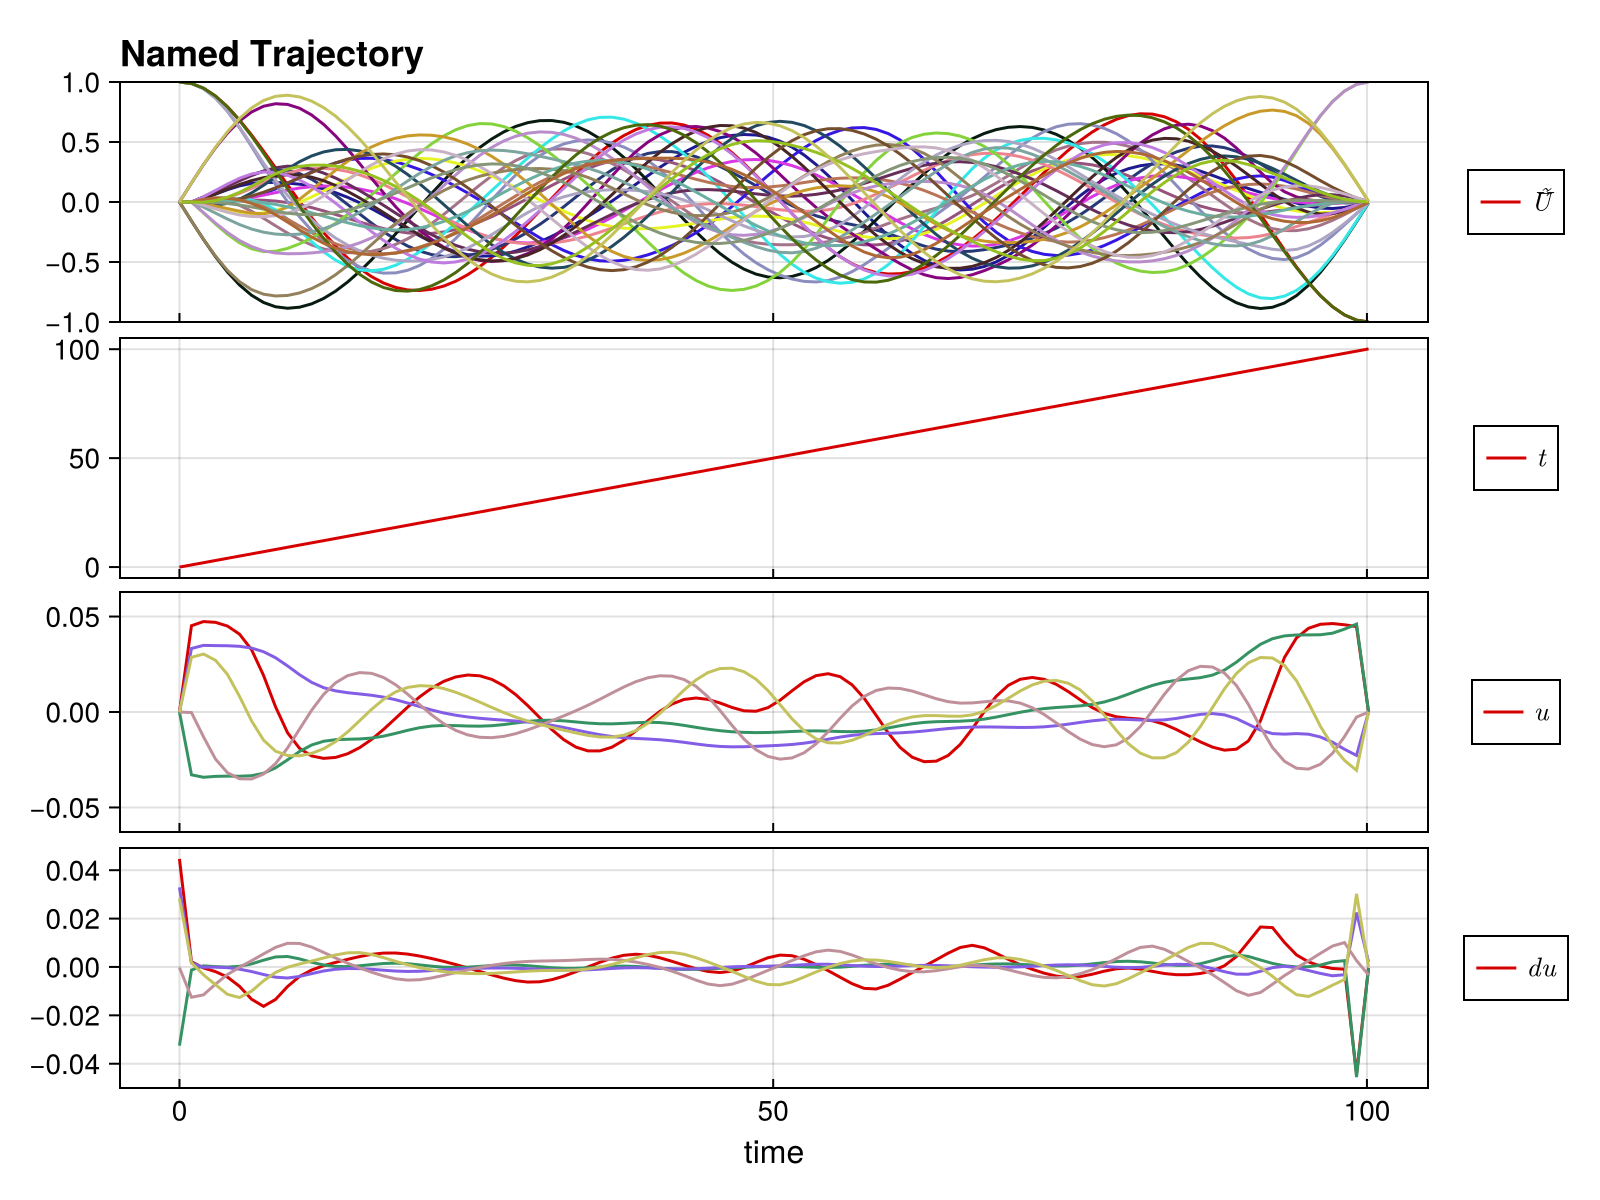

In [31]:
plot(qcp.prob.trajectory, merge_labels=true)

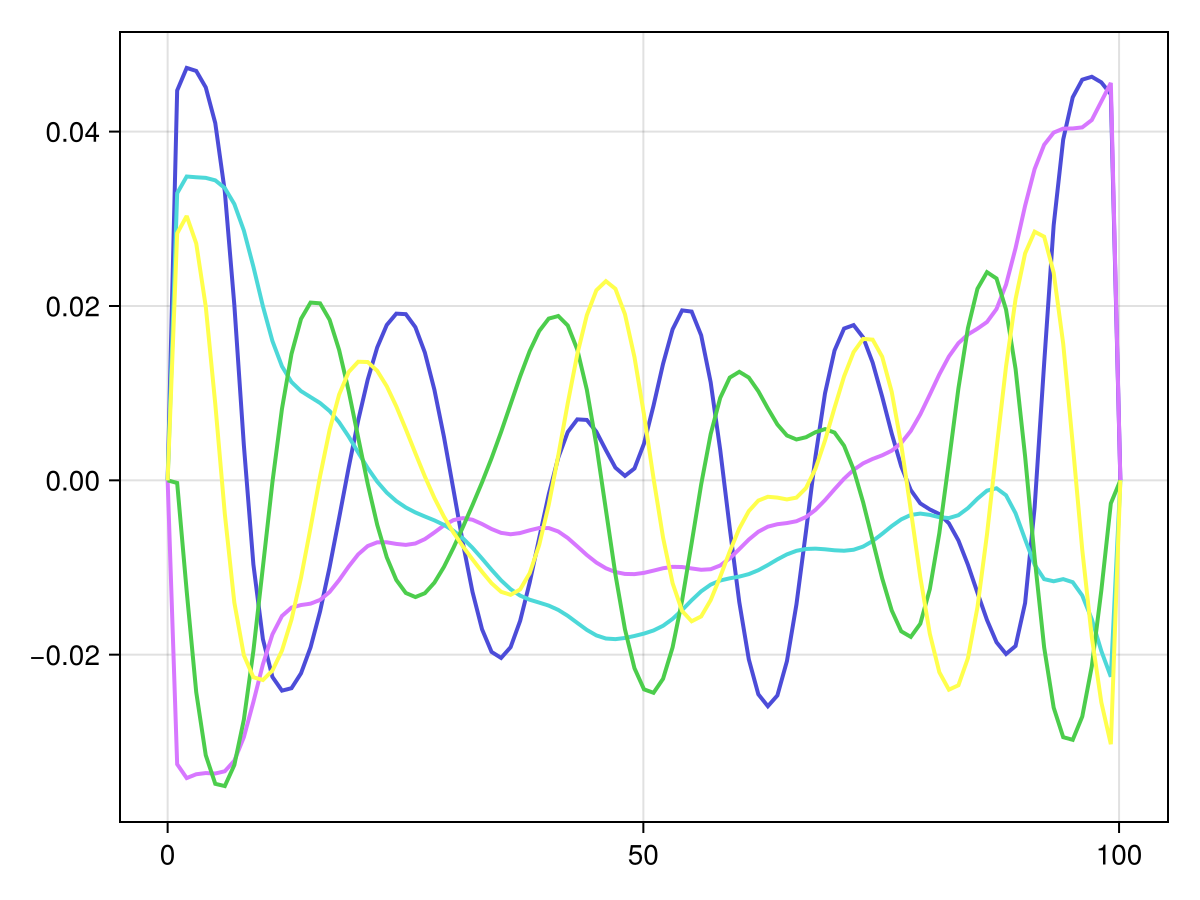

In [32]:
ts = qcp.qtraj.solution.t
series(ts, Piccolo.sample(qcp.qtraj.pulse, ts))

In [33]:
collect(qcp.qtraj.solution[:U])

101-element Vector{Matrix{ComplexF64}}:
 [1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 1.0 + 0.0im 0.0 + 0.0im; 0.0 + 0.0im 0.0 + 0.0im 0.0 + 0.0im 1.0 + 0.0im]
 [0.9872896745863311 - 0.15659216636004086im -0.01383330552127574 - 0.000167769711403512im -0.013644001929656695 + 0.018982568669231523im 0.00023848771046592772 - 0.0002232111965374148im; 0.014341104380228124 - 0.0010595114958343176im 0.9862948274630144 + 0.15661472687398645im -0.011708878882061378 - 0.0425093442078481im -0.01877030105240079 + 0.013823328657803152im; 0.01888897774187502 + 0.013202278565647891im 0.011262415731750162 - 0.04298954787373809im 0.9862948463417087 - 0.15659824948425974im -0.013907281135138474 - 0.00012245700202985184im; 0.00024672695479489035 + 0.0002180293174094137im 0.013801064463769351 + 0.018372249256216923im 0.014415076927569034 - 0.0010153835866018208im 0.9872888852662386 + 0.15660049249300717im]
 [0.947623694699304 - 0